<a href="https://colab.research.google.com/github/prosandnoobs/network-intrusion-eda/blob/main/network-intrusion-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Menginstal library kagglehub (jika belum ada)
!pip install kagglehub

import kagglehub
import os

print("Memulai proses download... (Ini mungkin memakan waktu beberapa menit)")

# Mendownload dataset versi terbaru dari Kaggle
path = kagglehub.dataset_download("dhoogla/csecicids2018")
print("\nDownload selesai! Dataset disimpan di:", path)

# Melihat daftar file yang ada di dalam folder tersebut
print("\nDaftar file yang tersedia di dataset:")
file_list = os.listdir(path)
for file in file_list:
    print("-", file)

Memulai proses download... (Ini mungkin memakan waktu beberapa menit)
Using Colab cache for faster access to the 'csecicids2018' dataset.

Download selesai! Dataset disimpan di: /kaggle/input/csecicids2018

Daftar file yang tersedia di dataset:
- DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
- DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
- DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
- Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet
- Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
- Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
- Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
- DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
- Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
- Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet


In [7]:
import pandas as pd
import os

#
dataset_path = "/kaggle/input/csecicids2018"
file_name = "Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet"
file_path = os.path.join(dataset_path, file_name)

print(f"Membaca file: {file_name}...")

# Membaca file parquet ke dalam Pandas DataFrame
df = pd.read_parquet(file_path)

print("\nData berhasil dimuat!")
print(f"Total aris dan kolom: {df.shape}")

# Mengecek jenis-jenis label (Normal vs Serangan) dan jumlahnya
print("\nDistribusi Label (Lalu Lintas Jaringan):")
print(df['Label'].value_counts())

# Menampilkan 5 baris pertama untuk mengintip isi data
display(df.head())

Membaca file: Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet...

Data berhasil dimuat!
Total aris dan kolom: (619346, 78)

Distribusi Label (Lalu Lintas Jaringan):
Label
Benign            525245
SSH-Bruteforce     94048
FTP-BruteForce        53
Name: count, dtype: int64


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,112641719,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56320860.0,139.300034,56320958,56320761,Benign
1,0,112641466,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56320732.0,114.551300,56320814,56320652,Benign
2,0,112638623,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56319312.0,301.934601,56319525,56319098,Benign
3,6,6453966,15,10,1239,2273,744,0,82.599998,196.741241,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,6,8804066,14,11,1143,2209,744,0,81.642860,203.745544,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [8]:
import numpy as np

print("Data Cleaning is starting...")

# 1. Hapus hidden space di awal/akhir nama kolom
df.columns = df.columns.str.strip()
print("- Nama kolom berhasil dirapikan.")

# 2. Ubah nilai infinity to NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Check total NaN data
missing_values = df.isna().sum().sum()
print(f"- Ditemukan {missing_values} sel dengan nilai kosong atau Infinity.")

# 4. Drop baris yang ada nilai kosong
df.dropna(inplace=True)

# 5. Check data size after cleaning
print("\nData Cleaning done!")
print(f"Total baris yang siap dianalisis: {df.shape[0]}")

Data Cleaning is starting...
- Nama kolom berhasil dirapikan.
- Ditemukan 0 sel dengan nilai kosong atau Infinity.

Data Cleaning done!
Total baris yang siap dianalisis: 619346


Making data visualization...


/tmp/ipykernel_8727/1783092391.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Label', palette='viridis')
/tmp/ipykernel_8727/1783092391.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Label', y='Flow Duration', estimator='mean', palette='magma')


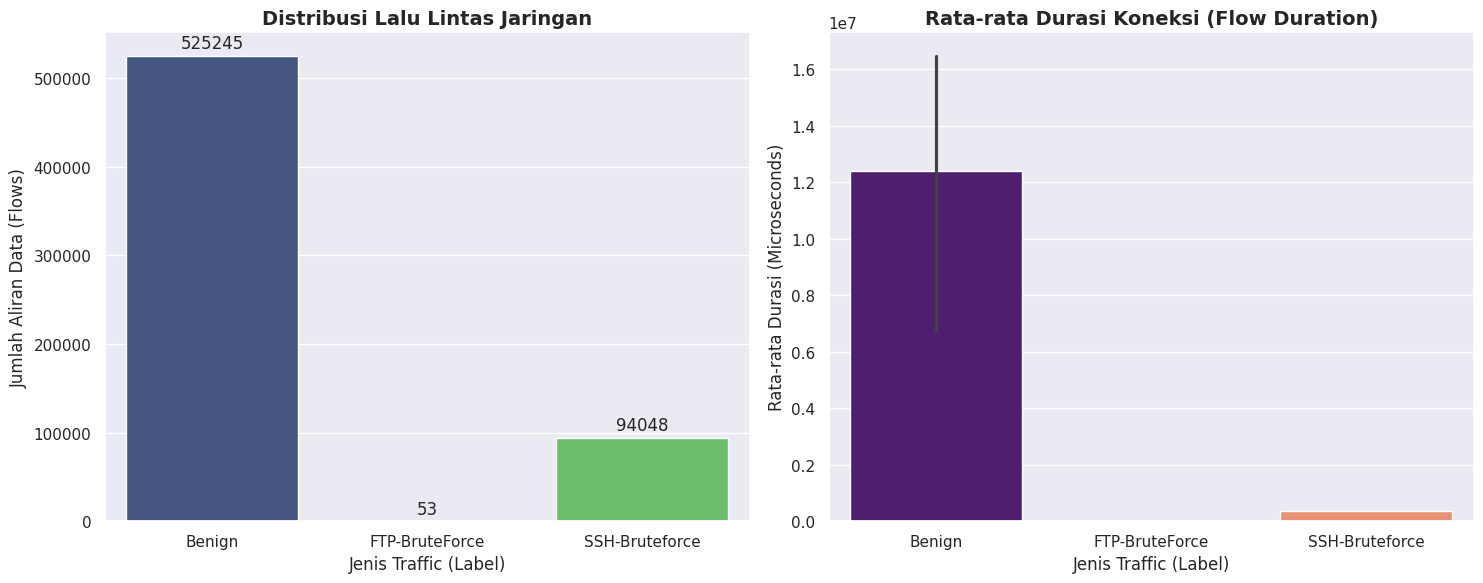

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Making data visualization...")

# Mengatur tema dan ukuran kanvas visual
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15, 6))

# Distribusi Jenis Traffic
plt.subplot(1, 2, 1) # Bagi kanvas jadi 1 baris, 2 kolom, posisi 1
ax = sns.countplot(data=df, x='Label', palette='viridis')
plt.title('Distribusi Lalu Lintas Jaringan', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Traffic (Label)')
plt.ylabel('Jumlah Aliran Data (Flows)')

# Add angka detail di atas setiap batang grafik
for p in ax.patches:
  ax.annotate(format(p.get_height(), '.0f'),
              (p.get_x() + p.get_width() / 2., p.get_height()),
              ha = 'center', va = 'center',
              xytext = (0, 9),
              textcoords = 'offset points')

# Rata-rata Durasi Koneksi
plt.subplot(1, 2, 2) # posisi ke 2 (sebelah kanan)
# Gunakan estimator 'mean' untuk menghitung rata-rata
sns.barplot(data=df, x='Label', y='Flow Duration', estimator='mean', palette='magma')
plt.title('Rata-rata Durasi Koneksi (Flow Duration)', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Traffic (Label)')
plt.ylabel('Rata-rata Durasi (Microseconds)')

# Menyesuaikan jarak antar grafik
plt.tight_layout()
plt.show()

Memulai Feature Engineering dan Analisi Korelasi...
- Label berhasil dikonversi menjadi biner (Is_Attack).

Top 5 Fitur yang paling berindikasi TINGGI sebagai serangan (Korelasi Positif)
Fwd Act Data Packets     0.723199
Fwd Seg Size Min         0.712370
Init Fwd Win Bytes       0.626876
Fwd Packet Length Max    0.449454
PSH Flag Count           0.360247
Name: Is_Attack, dtype: float64

Top 5 Fitur yang paling berindikasi traffic NORMAL (Korelasi Negatif)
Fwd Avg Packets/Bulk   NaN
Fwd Avg Bulk Rate      NaN
Bwd Avg Bytes/Bulk     NaN
Bwd Avg Packets/Bulk   NaN
Bwd Avg Bulk Rate      NaN
Name: Is_Attack, dtype: float64

Membuat Correlation Heatmap...


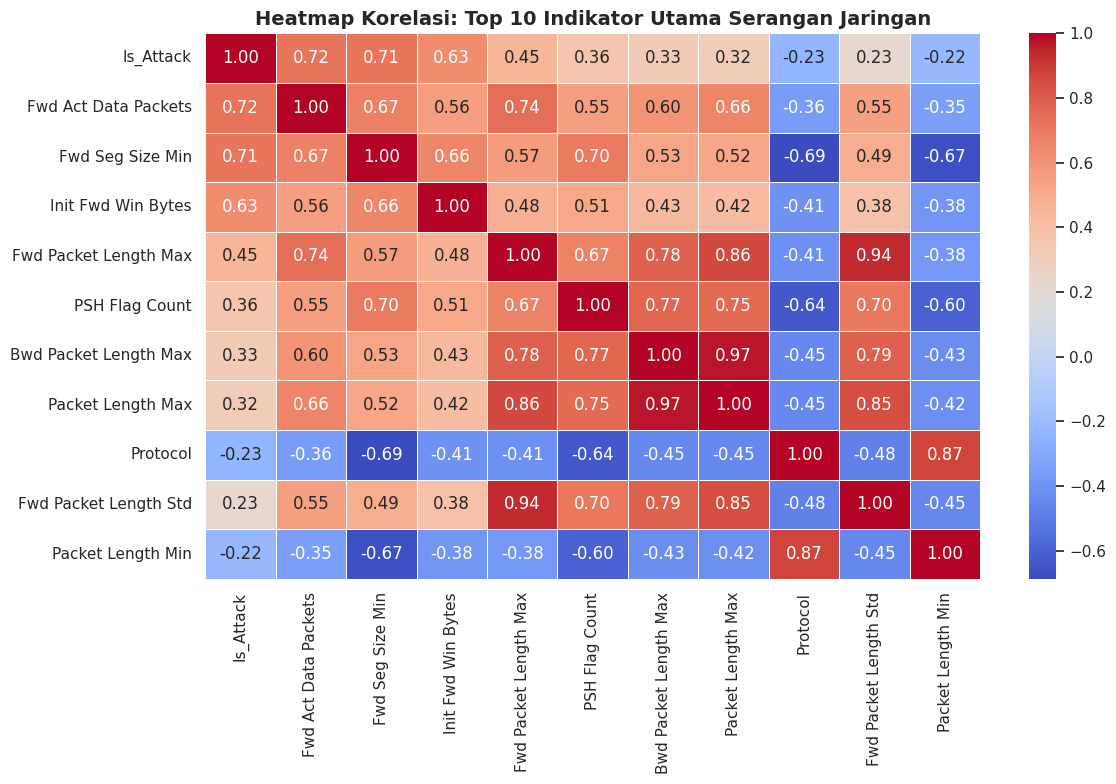

In [10]:
print("Memulai Feature Engineering dan Analisi Korelasi...")

# 1. Ubah teks 'Label' menjadi angka biner (0 = Normal, 1 = Serangan)
# Komputer/Algoritma membutuhkan angka ukur untuk menghitung korelasi matematis
df['Is_Attack'] = df['Label'].apply(lambda x:0 if x == 'Benign' else 1)
print("- Label berhasil dikonversi menjadi biner (Is_Attack).")

# 2. Mengambil hanya kolom yang berisi angka (numerik)
numeric_cols = df.select_dtypes(include=['number'])

# Menghitung korelasi semua fitur terhadap kolom target 'Is_Attack'
# Semakin mendekati angka 1 atau -1, hubungan semakin kuat
correlation_with_attack = numeric_cols.corr()['Is_Attack'].sort_values(ascending=False)

print("\nTop 5 Fitur yang paling berindikasi TINGGI sebagai serangan (Korelasi Positif)")
print(correlation_with_attack[1:6]) #Index 0 diabaikan karena itu Is_Attack vs Is_Attack (pasti 1.0)

print("\nTop 5 Fitur yang paling berindikasi traffic NORMAL (Korelasi Negatif)")
print(correlation_with_attack[-5:])

# 3. Membuat Visualisasi Heatmap untuk Top 10 Fitur Terpenting
print("\nMembuat Correlation Heatmap...")
# Mengambil 10 kolom dengan nilai korelasi absolut tertinggi
top_features = correlation_with_attack.abs().sort_values(ascending=False).index[0:11]

plt.figure(figsize=(12, 8))
# Membuat heatmap, fmt =".2f" agar angka desimal limit 2 digit belakang koma
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Heatmap Korelasi: Top 10 Indikator Utama Serangan Jaringan", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()